In [48]:
# Useful imports
import matplotlib.pyplot as plt
import numpy as np
import camb
from camb import model, initialpower

In [49]:
# Setting Planck cosmology in CAMB
pars = camb.read_ini('https://raw.githubusercontent.com/cmbant/CAMB/master/inifiles/planck_2018.ini')

In [50]:
# Computing the density parameter of matter
Omega_m = pars.omegab + pars.omegac
print(r'Omega_m =', Omega_m)

Omega_m = 0.31439960415054924


In [51]:
# Computing the linear matter power spectrum
# Note non-linear corrections couples to smaller scales than you want
pars.set_matter_power(redshifts=[0., 0.8], kmax=2.0)

# Linear spectra
pars.NonLinear = model.NonLinear_none
results = camb.get_results(pars)
kh, z, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)
s8 = np.array(results.get_sigma8())

print('s8 =', s8)
print('The first value is at z=0.8, the second at z=0, since redshifts have been resorted.')

Note: redshifts have been re-sorted (earliest first)
s8 = [0.53964506 0.81188935]
The first value is at z=0.8, the second at z=0, since redshifts have been resorted.


In [52]:
#Non-Linear spectra (Halofit)
pars.NonLinear = model.NonLinear_both
results_non_lin = camb.get_results(pars)
results_non_lin.calc_power_spectra(pars)
kh_nonlin, z_nonlin, pk_nonlin = results_non_lin.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)

In [53]:
s8_non_lin = np.array(results_non_lin.get_sigma8())
print('s8_non_lin =', s8_non_lin)

s8_non_lin = [0.53965098 0.81189826]


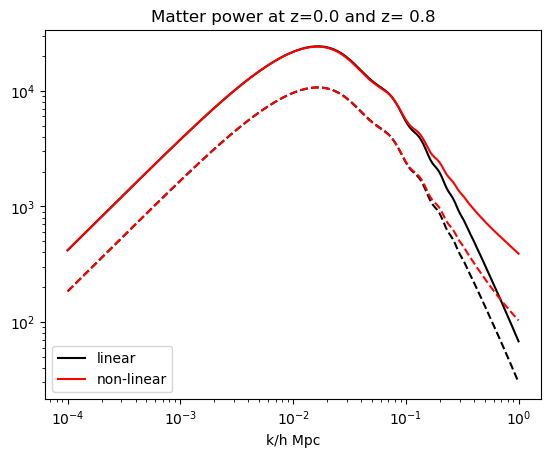

In [54]:
for i, (redshift, line) in enumerate(zip(z,['-','--'])):
    plt.loglog(kh, pk[i,:], color='k', ls = line)
    plt.loglog(kh_nonlin, pk_nonlin[i,:], color='r', ls = line)
plt.xlabel('k/h Mpc');
plt.legend(['linear','non-linear'], loc='lower left');
plt.title('Matter power at z=%s and z= %s'%tuple(z));

We will not use the halo fit CAMB uses for non linear corrections. These code uses halo of dark matter and it is more relevant on small scales.

In [55]:
# Computing fsigma8
fsigma8 = results.get_fsigma8()

# Computing the growth factor f
f = fsigma8/s8

# Printing the growth factor f
print('f =', f)

f = [0.84235724 0.52871158]


In [56]:
# Fixing the bias parameter
b = 1.5
# COME LO RICAVO/FISSO IN MODO INDIPEPENDENTE?

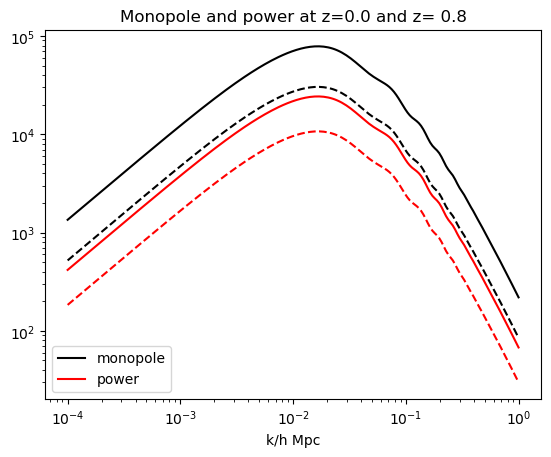

In [59]:
# Computing the monopole (l=0) for all redshifts
monopole = (b**2+2*b*f[:, None]/3+f[:, None]**2/5)*pk

# Plotting the monopole at all redshifts VS the power spectrum
for i, (redshift, line) in enumerate(zip(z,['-','--'])):
    plt.loglog(kh, monopole[i,:], color='k', ls = line)
    plt.loglog(kh, pk[i,:], color='r', ls = line)
plt.xlabel('k/h Mpc');
plt.legend(['monopole','power'], loc='lower left');
plt.title('Monopole and power at z=%s and z= %s'%tuple(z));


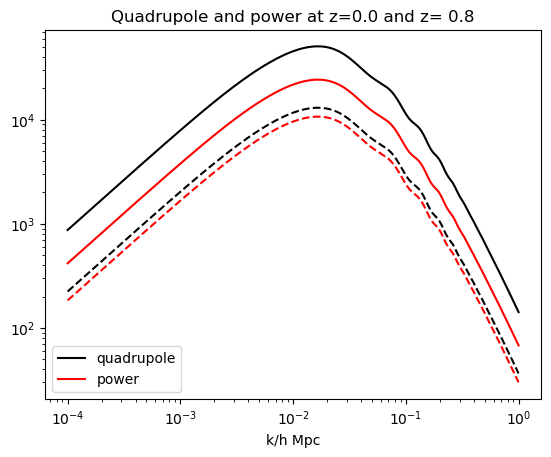

In [60]:
# Computing the quadrupole (l=2) for all redshifts
quadrupole = (4*b*f[:, None]/3+4*f[:, None]**2/7)*pk

# Plotting the quadrupole at all redshifts VS the power spectrum
for i, (redshift, line) in enumerate(zip(z,['-','--'])):
    plt.loglog(kh, quadrupole[i,:], color='k', ls = line)
    plt.loglog(kh, pk[i,:], color='r', ls = line)
plt.xlabel('k/h Mpc');
plt.legend(['quadrupole','power'], loc='lower left');
plt.title('Quadrupole and power at z=%s and z= %s'%tuple(z));



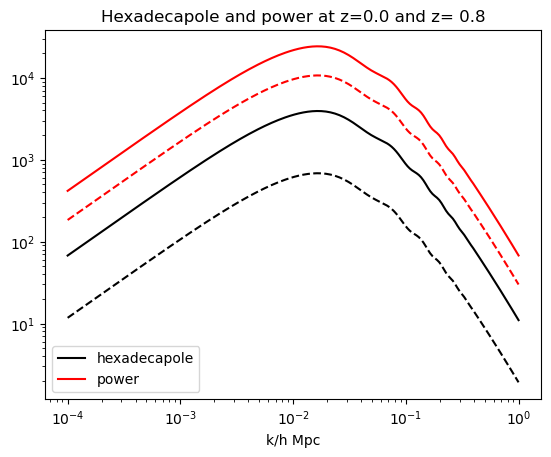

In [61]:
# Computing the hexadecapole (l=4) for all redshifts
hexadecapole = (8*f[:, None]**2/35)*pk

# Plotting the hexadecapole at all redshifts VS the power spectrum
for i, (redshift, line) in enumerate(zip(z,['-','--'])):
    plt.loglog(kh, hexadecapole[i,:], color='k', ls = line)
    plt.loglog(kh, pk[i,:], color='r', ls = line)
plt.xlabel('k/h Mpc');
plt.legend(['hexadecapole','power'], loc='lower left');
plt.title('Hexadecapole and power at z=%s and z= %s'%tuple(z));

